In [1]:

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving heards_structured_cleaned_07.csv to heards_structured_cleaned_07.csv
User uploaded file "heards_structured_cleaned_07.csv" with length 40214399 bytes


In [2]:
import pandas as pd

# Load your dataset (make sure you've uploaded it)
df = pd.read_csv("heards_structured_cleaned_07.csv")

# Get total number of rows
total_rows = len(df)

# Calculate data types
column_types = df.dtypes

# Calculate percent filled
percent_filled = df.notnull().sum() / total_rows * 100

# Combine into a summary DataFrame
summary_df = pd.DataFrame({
    "Data Type": column_types,
    "Total Rows": total_rows,
    "% Filled": percent_filled
})

# Display it
print(summary_df)


              Data Type  Total Rows    % Filled
updatedDate      object      195672  100.000000
start_date       object      195672   99.428125
end_date         object      195672   99.269696
action_type      object      195672  100.000000
party            object      195672   91.151008
price           float64      195672  100.000000
price_basis      object      195672   80.918578
grade           float64      195672   89.180874
incoterm         object      195672   82.203892
location         object      195672   82.739482
volume_min      float64      195672   61.088965
volume_max      float64      195672   61.088965
frequency_tag    object      195672   60.760865
headline         object      195672  100.000000


In [3]:
# Count unique values in the 'price_basis' column
price_basis_counts = df['price_basis'].value_counts(dropna=False)

# Display the result
print(price_basis_counts)


price_basis
MOPS 380     116460
MOPS 180      37939
NaN           37337
3              3816
MOPAG 380       104
F                13
MOPAG 180         3
Name: count, dtype: int64


In [5]:
# Temporarily fill NaN in price_basis to include them in groupby
df_temp = df.copy()
df_temp["price_basis"] = df_temp["price_basis"].fillna("NaN")

# Group by 'price_basis' and describe 'price'
price_summary_by_basis = df_temp.groupby("price_basis")["price"].describe()

# Display the result, rounded for clarity
print(price_summary_by_basis.round(2))


                count    mean     std     min     25%     50%     75%     max
price_basis                                                                  
3              3816.0    7.98    7.06  -20.00    6.22    6.45    6.45   49.00
F                13.0  348.55    0.09  348.26  348.57  348.57  348.57  348.57
MOPAG 180         3.0  333.33  288.68    0.00  250.00  500.00  500.00  500.00
MOPAG 380       104.0   21.28    9.60    0.00   14.00   20.00   26.44   43.00
MOPS 180      37939.0   42.41  115.31 -100.00    0.00    3.00    9.00  670.00
MOPS 380     116460.0   64.39  134.09  -31.00    1.25    5.00   17.00  673.00
NaN           37337.0  286.78  103.38 -122.75  303.08  323.18  348.81  546.63


In [6]:
df_cleaned = df[~df["price_basis"].isin(["3", "F", "MOPAG 180", "MOPAG 380"])]


In [11]:
# Copy cleaned DataFrame
df_temp = df_cleaned.copy()

# Fill NaN in price_basis for grouping
df_temp["price_basis"] = df_temp["price_basis"].fillna("NaN")

# Group and describe prices
price_stats = df_temp.groupby("price_basis")["price"].describe().round(2)

# Print the grouped summary
print(price_stats)

# Print overall total number of rows
print("\nTotal rows in cleaned dataset:", len(df_temp))


                count    mean     std     min     25%     50%     75%     max
price_basis                                                                  
MOPS 180      37939.0   42.41  115.31 -100.00    0.00    3.00    9.00  670.00
MOPS 380     116460.0   64.39  134.09  -31.00    1.25    5.00   17.00  673.00
NaN           37337.0  286.78  103.38 -122.75  303.08  323.18  348.81  546.63

Total rows in cleaned dataset: 191736


In [12]:
# Filter the cleaned DataFrame for rows with NaN as price_basis
nan_rows = df_cleaned[df_cleaned["price_basis"].isna()]

# Count rows with price <= 0
count_le_zero = (nan_rows["price"] <= 0).sum()

print("Rows with price ≤ 0 in NaN category:", count_le_zero)


Rows with price ≤ 0 in NaN category: 302


In [13]:
df_cleaned = df_cleaned[~((df_cleaned["price_basis"].isna()) & (df_cleaned["price"] <= 0))]


In [14]:
# Copy cleaned DataFrame
df_temp = df_cleaned.copy()

# Fill NaN in price_basis for grouping
df_temp["price_basis"] = df_temp["price_basis"].fillna("NaN")

# Group and describe prices
price_stats = df_temp.groupby("price_basis")["price"].describe().round(2)

# Print the grouped summary
print(price_stats)

# Print overall total number of rows
print("\nTotal rows in cleaned dataset:", len(df_temp))


                count    mean     std    min     25%     50%     75%     max
price_basis                                                                 
MOPS 180      37939.0   42.41  115.31 -100.0    0.00    3.00    9.00  670.00
MOPS 380     116460.0   64.39  134.09  -31.0    1.25    5.00   17.00  673.00
NaN           37035.0  289.42   99.55    0.2  303.08  323.18  348.81  546.63

Total rows in cleaned dataset: 191434


In [19]:
# Filter the cleaned DataFrame for rows with NaN as price_basis
nan_rows = df_cleaned[df_cleaned["price_basis"].isna()]

# Count rows with price <= 0
count_le_zero = (nan_rows["price"] <= 100).sum()

print("Rows with price ≤ 0 in NaN category:", count_le_zero)


Rows with price ≤ 0 in NaN category: 2890


In [20]:
# Filter rows with NaN price_basis and price < 100
nan_under_100 = df_cleaned[(df_cleaned["price_basis"].isna()) & (df_cleaned["price"] < 100)]

# Display 5 random samples
print(nan_under_100.sample(5, random_state=42))


       updatedDate  start_date    end_date action_type party      price  \
179676  2024-08-26  2024-11-01  2024-11-01       Offer   NaN  14.062476   
183021  2022-07-25  2022-11-01  2022-11-01       Offer   NaN  14.062476   
190370  2018-12-28  2018-11-01  2018-12-01       Offer   NaN  95.045457   
194378  2017-10-26  2017-11-10  2017-11-14         Bid   NaN  60.479801   
195533  2017-07-03  2017-08-24  2017-08-28       Offer   NaN  90.345868   

       price_basis  grade incoterm location  volume_min  volume_max  \
179676         NaN    NaN      NaN      NaN         NaN         NaN   
183021         NaN    NaN      NaN      NaN         NaN         NaN   
190370         NaN    NaN      NaN      NaN         NaN         NaN   
194378         NaN    NaN      NaN      NaN         NaN         NaN   
195533         NaN    NaN      NaN      NaN         NaN         NaN   

       frequency_tag                                           headline  
179676           NaN       platts singapore fuel

In [27]:
# Define thresholds and ranges
thresholds = [10, 50, 100, 150,200,300,400]
previous = 0

# Filter only rows with NaN price_basis
nan_basis_rows = df_cleaned[df_cleaned["price_basis"].isna()]

for threshold in thresholds:
    # Select rows within the exclusive range (previous, threshold)
    filtered = nan_basis_rows[
        (nan_basis_rows["price"] >= previous) & (nan_basis_rows["price"] < threshold)
    ]

    # Count number of missing (NaN) columns in each row
    null_counts = filtered.isnull().sum(axis=1)

    # Count how many rows have 1, 2, 3, ... missing columns
    value_counts = null_counts.value_counts().sort_index()

    print(f"\nPrice range: {previous} ≤ price < {threshold}")
    print(value_counts)

    # Update previous threshold
    previous = threshold



Price range: 0 ≤ price < 10
3     1
4    31
5     6
6     3
7    12
8    53
9     3
Name: count, dtype: int64

Price range: 10 ≤ price < 50
4     141
7       3
8    1669
9       7
Name: count, dtype: int64

Price range: 50 ≤ price < 100
4     34
5      5
6      5
8    906
9     11
Name: count, dtype: int64

Price range: 100 ≤ price < 150
8    2708
9      40
Name: count, dtype: int64

Price range: 150 ≤ price < 200
8    1204
9      47
Name: count, dtype: int64

Price range: 200 ≤ price < 300
4       97
5       10
6       28
7        2
8     1325
9      126
10       7
Name: count, dtype: int64

Price range: 300 ≤ price < 400
4    7757
5    3854
6    7936
7      87
8    8754
9      20
Name: count, dtype: int64


In [29]:
# Total dataset before deletion
initial_total = len(df_cleaned)
percent_filled_total_before = df_cleaned.notnull().sum() / initial_total * 100
summary_before = pd.DataFrame({
    "Total Rows": initial_total,
    "% Filled": percent_filled_total_before.round(2)
})

# --- Filter out bad NaN rows ---
nan_rows = df_cleaned[df_cleaned["price_basis"].isna()]
missing_counts = nan_rows.isnull().sum(axis=1)
to_delete = nan_rows[(nan_rows["price"] < 100) & (missing_counts >= 4)]
to_keep = nan_rows.drop(to_delete.index)

# --- Create new filtered dataset ---
non_nan_rows = df_cleaned[~df_cleaned["price_basis"].isna()]
df_filtered = pd.concat([non_nan_rows, to_keep], axis=0)
filtered_total = len(df_filtered)

# % filled after deletion
percent_filled_total_after = df_filtered.notnull().sum() / filtered_total * 100
summary_after = pd.DataFrame({
    "Total Rows": filtered_total,
    "% Filled": percent_filled_total_after.round(2)
})

# --- Summary for retained NaN rows (imputation candidates) ---
retained_nan_count = len(to_keep)
percent_filled_nan = to_keep.notnull().sum() / retained_nan_count * 100
summary_nan_retained = pd.DataFrame({
    "Total Rows (retained NaN)": retained_nan_count,
    "% Filled": percent_filled_nan.round(2)
})

# --- Output summaries ---
print("\n=== BEFORE FILTERING ===")
print(summary_before)

print("\n=== AFTER FILTERING (Deleted bad NaN rows) ===")
print(summary_after)

print("\n=== RETAINED NaN price_basis ROWS (To Be Imputed) ===")
print(summary_nan_retained)

# Also display deletion impact
print("\nNaN rows before:", len(nan_rows))
print("NaN rows deleted:", len(to_delete))
print("NaN rows retained:", len(to_keep))



=== BEFORE FILTERING ===
               Total Rows  % Filled
updatedDate        191434    100.00
start_date         191434     99.43
end_date           191434     99.31
action_type        191434    100.00
party              191434     91.11
price              191434    100.00
price_basis        191434     80.65
grade              191434     91.10
incoterm           191434     81.97
location           191434     83.57
volume_min         191434     62.39
volume_max         191434     62.39
frequency_tag      191434     60.69
headline           191434    100.00

=== AFTER FILTERING (Deleted bad NaN rows) ===
               Total Rows  % Filled
updatedDate        188545    100.00
start_date         188545     99.42
end_date           188545     99.31
action_type        188545    100.00
party              188545     92.38
price              188545    100.00
price_basis        188545     81.89
grade              188545     92.38
incoterm           188545     83.11
location           188545 

In [30]:
# Recompute the deletion condition explicitly
nan_rows = df_cleaned[df_cleaned["price_basis"].isna()]
missing_counts = nan_rows.isnull().sum(axis=1)

# Define rows to delete (price < 100 and ≥ 4 missing fields)
to_delete = nan_rows[(nan_rows["price"] < 100) & (missing_counts >= 4)]

# Drop them from the dataset
df_cleaned = df_cleaned.drop(to_delete.index).reset_index(drop=True)

# Optional: Confirm size
print("✅ Deletion complete.")
print("Remaining rows:", len(df_cleaned))


✅ Deletion complete.
Remaining rows: 188545


In [31]:
# Total rows after deletion
total_rows_after = len(df_cleaned)

# Calculate % filled per column
percent_filled_final = df_cleaned.notnull().sum() / total_rows_after * 100

# Create summary DataFrame
final_summary = pd.DataFrame({
    "Total Rows": total_rows_after,
    "% Filled": percent_filled_final.round(2)
})

# Display the result
print(final_summary)


               Total Rows  % Filled
updatedDate        188545    100.00
start_date         188545     99.42
end_date           188545     99.31
action_type        188545    100.00
party              188545     92.38
price              188545    100.00
price_basis        188545     81.89
grade              188545     92.38
incoterm           188545     83.11
location           188545     84.73
volume_min         188545     63.35
volume_max         188545     63.35
frequency_tag      188545     61.62
headline           188545    100.00


In [32]:
# Convert to datetime (in case they aren't already)
df_cleaned["updatedDate"] = pd.to_datetime(df_cleaned["updatedDate"], errors="coerce")
df_cleaned["start_date"] = pd.to_datetime(df_cleaned["start_date"], errors="coerce")
df_cleaned["end_date"] = pd.to_datetime(df_cleaned["end_date"], errors="coerce")

# Display min and max for each
print("📅 Date Ranges:")
print("updatedDate:", df_cleaned["updatedDate"].min(), "→", df_cleaned["updatedDate"].max())
print("start_date :", df_cleaned["start_date"].min(), "→", df_cleaned["start_date"].max())
print("end_date   :", df_cleaned["end_date"].min(), "→", df_cleaned["end_date"].max())


📅 Date Ranges:
updatedDate: 2017-06-15 00:00:00 → 2025-05-23 00:00:00
start_date : 2017-01-01 00:00:00 → 2025-12-29 00:00:00
end_date   : 2017-01-01 00:00:00 → 2025-12-31 00:00:00


In [33]:
# Ensure dates are datetime
df_cleaned["start_date"] = pd.to_datetime(df_cleaned["start_date"], errors="coerce")
df_cleaned["end_date"] = pd.to_datetime(df_cleaned["end_date"], errors="coerce")

# Condition: start_date < end_date
valid_range_mask = df_cleaned["start_date"] < df_cleaned["end_date"]

# Count valid and total
valid_range_count = valid_range_mask.sum()
total_rows_with_dates = df_cleaned[["start_date", "end_date"]].dropna().shape[0]
percentage_valid = (valid_range_count / total_rows_with_dates) * 100

# Output
print("Rows with start_date < end_date:", valid_range_count)
print("Total rows with non-null start & end dates:", total_rows_with_dates)
print(f"Percentage of valid date ranges: {percentage_valid:.2f}%")


Rows with start_date < end_date: 152562
Total rows with non-null start & end dates: 186179
Percentage of valid date ranges: 81.94%


In [38]:
# Make sure Pandas displays the full text in 'headline'
pd.set_option('display.max_colwidth', None)

# Filter and show selected columns with full headlines
invalid_date_rows = df_cleaned[df_cleaned["start_date"] > df_cleaned["end_date"]]
print(invalid_date_rows[["updatedDate", "start_date", "end_date", "headline"]].sample(5))


       updatedDate start_date   end_date  \
5854    2025-01-22 2025-02-26 2025-02-15   
11219   2024-09-27 2024-10-23 2024-10-18   
31734   2023-05-11 2023-06-27 2023-06-03   
165167  2017-09-15 2017-10-28 2017-10-01   
120511  2019-03-13 2019-04-28 2019-04-01   

                                                                                                                        headline  
5854                          Platts HSFO 380CST: Feb 11-Feb 15 pegged at MOPS 9, Feb Avg 9.26, Mar Avg 17.01, Flat Price 486.26  
11219   Platts HSFO 180CST: Oct 22-Oct 27 pegged at MOPS 17.75, Oct Avg 14.48, Nov Avg 26.23, Flat Price 424.48, 380CST MOPS 33.  
31734   Platts HSFO 380cst FOB Straits 15-30, VITOLSG bids Jun 5-Jun 9 100% MOPS 380 5 Day $0.00  for 20-20 "inco" OCO  7:59:02.  
165167  Asia 1005: Platts HSFO 380cst FOB Straits 15-30, VITOLSG lowers offer Oct 5-Oct 9 100% MOPS 380 BalMnth Bal Month $1.50   
120511  Asia 620: Platts HSFO 380cst FOB Straits 15-30, GLENCORESG lowers offer 

In [39]:
# Filter valid date ranges
valid_date_rows = df_cleaned[
    (df_cleaned["start_date"].notnull()) &
    (df_cleaned["end_date"].notnull()) &
    (df_cleaned["start_date"] < df_cleaned["end_date"])
]

# Print 5 examples with headline
print(valid_date_rows[["updatedDate", "start_date", "end_date", "headline"]].sample(5))

# Confirm %
valid_pct = len(valid_date_rows) / 186179 * 100
print(f"\n✅ Percentage of rows with start_date < end_date: {valid_pct:.2f}%")


       updatedDate start_date   end_date  \
15991   2024-06-06 2024-06-24 2024-06-28   
39941   2022-10-20 2022-11-03 2022-11-07   
98117   2019-11-05 2019-11-25 2019-11-29   
122711  2019-02-14 2019-03-01 2019-03-05   
158207  2017-12-11 2017-12-26 2017-12-30   

                                                                                                                        headline  
15991   Platts HSFO 380cst FOB Straits 15-30, SIETCO offers Jun 24-Jun 28 100% MOPS 380 5 Day $18.00  for 20-20 "Shell GTC +65 8  
39941   Platts HSFO 380cst FOB Straits 15-30, GLENCORESG lowers offer Nov 4-Nov 8 100% MOPS 380 Flat Price $372.00  for 20-20 OC  
98117   Asia 404: Platts HSFO 380cst FOB Straits 15-30, VITOLSG lowers offer Nov 25-Nov 29 100% MOPS 380 BalMnth Bal Month $43.0  
122711  Asia 186: Platts HSFO 380cst FOB Straits 15-30, VITOLSG offers Mar 2-Mar 6 100% MOPS 380 BalMnth Bal Month $6.80  for 20  
158207  Asia 354: Platts HSFO 180cst FSU 15-30, TRAFI offers Dec 26-Dec 30 100% 

In [40]:
# Create a working copy
df_model_ready = df_cleaned.copy()

# Null out invalid date ranges in the copy
mask_invalid = df_model_ready["start_date"] > df_model_ready["end_date"]
df_model_ready.loc[mask_invalid, ["start_date", "end_date"]] = pd.NaT

# Recalculate % filled on the modified copy
total_rows = len(df_model_ready)
percent_filled = df_model_ready.notnull().sum() / total_rows * 100

# Display summary
summary_model_ready = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})

print(summary_model_ready)


               Total Rows  % Filled
updatedDate        188545    100.00
start_date         188545     85.84
end_date           188545     85.73
action_type        188545    100.00
party              188545     92.38
price              188545    100.00
price_basis        188545     81.89
grade              188545     92.38
incoterm           188545     83.11
location           188545     84.73
volume_min         188545     63.35
volume_max         188545     63.35
frequency_tag      188545     61.62
headline           188545    100.00


# Forecasting Start and End Dates from Headlines and Update Dates

## 🎯 Objective

Train a supervised ML model to infer the `start_date` and `end_date` of fuel oil transactions using:
- `headline` (natural language)
- `updatedDate` (date of report)

This allows us to fill in missing or invalid date fields in a cleaned dataset.

---

## ✅ Why This Works

- ~82% of the dataset has valid `start_date < end_date`, which we use as training data.
- The remaining 18% are either missing or invalid (e.g., `start_date > end_date`) and will be inferred.
- Headlines contain time windows in natural language (e.g., "Mar 2 - Mar 6").
- `updatedDate` reliably indicates the reference year of the transaction.

---

## 🛠️ Method

### Step 1: Prepare Targets
- Predict `start_doy` and `end_doy` = **Day of Year** of `start_date` and `end_date`.
- This keeps labels within a consistent [1–366] range.
- All dates will be reconstructed using:



### Step 2: Feature Engineering
- **Text Feature**: TF-IDF vectorization of `headline`
- **Numeric Feature**: `updatedDate.year` as integer

### Step 3: Modeling
- Use `Ridge` regression from `scikit-learn`
- Train two separate models: one for `start_doy`, one for `end_doy`

### Step 4: Inference
- Use trained models to predict `start_doy` and `end_doy` for rows where they are missing
- Reconstruct `start_date` and `end_date` using the inferred values

---

## 🔧 Tools

- `scikit-learn`: Feature engineering, model training
- `pandas`: Data prep and manipulation
- `datetime`: Date arithmetic
- `TfidfVectorizer`: Headline embedding

---

## 🧠 Notes

- GPU is **not required**
- This approach balances interpretability and speed
- TF-IDF is chosen for its simplicity and effectiveness on short text

---

## 📦 Outputs

- Two trained regression models
- Updated dataset with inferred `start_date` and `end_date` where previously missing or invalid


In [41]:
from datetime import datetime

# Step 1: Filter rows with all necessary fields
df_train = df_model_ready.dropna(subset=["start_date", "end_date", "headline", "updatedDate"]).copy()

# Step 2: Convert to day of year (targets)
df_train["start_doy"] = df_train["start_date"].dt.dayofyear
df_train["end_doy"] = df_train["end_date"].dt.dayofyear

# Step 3: Convert updatedDate to year (feature)
df_train["year"] = df_train["updatedDate"].dt.year

# Confirm target stats
print(df_train[["start_doy", "end_doy"]].describe())


           start_doy        end_doy
count  160579.000000  160579.000000
mean      177.821048     206.819839
std       106.566172     103.990409
min         1.000000       1.000000
25%        94.000000     120.000000
50%       177.000000     209.000000
75%       266.000000     296.000000
max       365.000000     366.000000


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# === 1. TF-IDF on headline ===
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_text = tfidf.fit_transform(df_train["headline"])

# === 2. Year as a numeric feature ===
X_year = df_train[["year"]].values  # shape: (n_samples, 1)

# Standardize year (optional, good for regression)
scaler = StandardScaler()
X_year_scaled = scaler.fit_transform(X_year)

# === 3. Combine features ===
from scipy.sparse import csr_matrix
X_combined = hstack([X_text, csr_matrix(X_year_scaled)])  # sparse matrix format

# === 4. Targets ===
y_start = df_train["start_doy"].values
y_end = df_train["end_doy"].values

# Confirm shapes
print("X shape:", X_combined.shape)
print("y_start shape:", y_start.shape)
print("y_end shape:", y_end.shape)


X shape: (160579, 5001)
y_start shape: (160579,)
y_end shape: (160579,)


In [43]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# === Split training and validation sets ===
X_train, X_val, y_start_train, y_start_val = train_test_split(X_combined, y_start, test_size=0.1, random_state=42)
_, _, y_end_train, y_end_val = train_test_split(X_combined, y_end, test_size=0.1, random_state=42)

# === Train Ridge models ===
model_start = Ridge(alpha=1.0)
model_start.fit(X_train, y_start_train)

model_end = Ridge(alpha=1.0)
model_end.fit(X_train, y_end_train)

# === Validation performance ===
y_start_pred = model_start.predict(X_val)
y_end_pred = model_end.predict(X_val)

mae_start = mean_absolute_error(y_start_val, y_start_pred)
mae_end = mean_absolute_error(y_end_val, y_end_pred)

print(f"Start DOY MAE: {mae_start:.2f} days")
print(f"End DOY MAE:   {mae_end:.2f} days")


Start DOY MAE: 13.80 days
End DOY MAE:   12.09 days


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from datetime import datetime, timedelta

# === 1. Select rows where start_date or end_date is missing ===
df_missing = df_model_ready[df_model_ready["start_date"].isna() | df_model_ready["end_date"].isna()].copy()

# === 2. Transform features ===
X_text_missing = tfidf.transform(df_missing["headline"])
X_year_missing = scaler.transform(df_missing["updatedDate"].dt.year.values.reshape(-1, 1))
X_combined_missing = hstack([X_text_missing, csr_matrix(X_year_missing)])

# === 3. Predict DOY ===
start_doy_pred = model_start.predict(X_combined_missing).round().clip(1, 366).astype(int)
end_doy_pred = model_end.predict(X_combined_missing).round().clip(1, 366).astype(int)

# === 4. Convert DOY to full date ===
def doy_to_date(year, doy):
    return datetime(int(year), 1, 1) + timedelta(days=int(doy) - 1)

df_missing["start_date_pred"] = [
    doy_to_date(year, doy) for year, doy in zip(df_missing["updatedDate"].dt.year, start_doy_pred)
]
df_missing["end_date_pred"] = [
    doy_to_date(year, doy) for year, doy in zip(df_missing["updatedDate"].dt.year, end_doy_pred)
]

# === 5. Preview result ===
print(df_missing[["updatedDate", "start_date_pred", "end_date_pred", "headline"]].head())


   updatedDate start_date_pred end_date_pred  \
16  2025-05-23      2025-06-28    2025-07-08   
21  2025-05-23      2025-06-20    2025-06-21   
60  2025-05-22      2025-06-05    2025-06-08   
70  2025-05-22      2025-06-12    2025-06-10   
77  2025-05-21      2025-06-10    2025-06-13   

                                                                                                                    headline  
16               Platts FUJ HSFO 380CST: Jun 22-Jun 26 pegged at FOB Fuj 25, Jun Avg 20.13, Jul Avg 36.63, Flat Price 426.48  
21                     Platts HSFO 380CST: Jun 7-Jun 11 pegged at MOPS -2.28, Jun Avg 1.26, Jul Avg 19.26, Flat Price 428.01  
60                  Platts HSFO 180cst FOB Straits 15-30, CHIMB offers Jun 6-Jun 10 100% MOPS 380 5 Day $8.00  for 20-20 "++  
70                     Platts HSFO 380CST: Jun 6-Jun 10 pegged at MOPS -2.28, Jun Avg 1.81, Jul Avg 19.61, Flat Price 428.56  
77  Platts HSFO 380cst FOB Straits 15-30, NOVUMC lowers offer Jun 11-Jun 15 

In [47]:
# Step 1: Correct bad inferences where predicted start > end
swap_mask = df_missing["start_date_pred"] > df_missing["end_date_pred"]
df_missing.loc[swap_mask, ["start_date_pred", "end_date_pred"]] = df_missing.loc[swap_mask, ["end_date_pred", "start_date_pred"]].values

# Step 2: Fill missing start/end dates in df_model_ready
for idx, row in df_missing.iterrows():
    if pd.isna(df_model_ready.at[idx, "start_date"]):
        df_model_ready.at[idx, "start_date"] = row["start_date_pred"]
    if pd.isna(df_model_ready.at[idx, "end_date"]):
        df_model_ready.at[idx, "end_date"] = row["end_date_pred"]

# Step 3: Re-check fill status
filled_summary = df_model_ready[["start_date", "end_date"]].notnull().mean() * 100
print("\n✅ Date fields after patching:")
print(filled_summary.round(2))



✅ Date fields after patching:
start_date    100.0
end_date      100.0
dtype: float64


In [48]:
# === 1. % Filled Summary ===
total_rows = len(df_model_ready)
percent_filled = df_model_ready.notnull().sum() / total_rows * 100
filled_summary = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})
print("📊 % Filled per Column:")
print(filled_summary)

# === 2. Sanity Check: Invalid or Null Dates ===
invalid_dates = df_model_ready[df_model_ready["start_date"] > df_model_ready["end_date"]]
null_dates = df_model_ready[df_model_ready["start_date"].isna() | df_model_ready["end_date"].isna()]

print(f"\n⚠️ Rows where start_date > end_date: {len(invalid_dates)}")
print(f"⚠️ Rows where start_date or end_date is null: {len(null_dates)}")


📊 % Filled per Column:
               Total Rows  % Filled
updatedDate        188545    100.00
start_date         188545    100.00
end_date           188545    100.00
action_type        188545    100.00
party              188545     92.38
price              188545    100.00
price_basis        188545     81.89
grade              188545     92.38
incoterm           188545     83.11
location           188545     84.73
volume_min         188545     63.35
volume_max         188545     63.35
frequency_tag      188545     61.62
headline           188545    100.00

⚠️ Rows where start_date > end_date: 1043
⚠️ Rows where start_date or end_date is null: 0


In [49]:
# Step 1: Filter rows where start_date > end_date
invalid_swaps = df_model_ready[df_model_ready["start_date"] > df_model_ready["end_date"]].copy()

# Step 2: Simulate swapping start and end
swapped_duration = (invalid_swaps["start_date"] - invalid_swaps["end_date"]).dt.days

# Step 3: Show summary stats
print("📊 Duration after swapping (start - end):")
print(swapped_duration.describe())


📊 Duration after swapping (start - end):
count    1043.000000
mean       25.918504
std        31.589802
min         1.000000
25%         9.000000
50%        18.000000
75%        30.000000
max       302.000000
dtype: float64


In [50]:
# Step 1: Identify rows where start_date > end_date
mask_invalid = df_model_ready["start_date"] > df_model_ready["end_date"]
invalid_rows = df_model_ready[mask_invalid].copy()

# Step 2: Calculate swapped duration
invalid_rows["duration_if_swapped"] = (invalid_rows["start_date"] - invalid_rows["end_date"]).dt.days

# Step 3: Split rows to keep vs. drop
to_keep = invalid_rows[invalid_rows["duration_if_swapped"] <= 30].copy()
to_drop = invalid_rows[invalid_rows["duration_if_swapped"] > 30].copy()

# Step 4: Perform swap only on rows to keep
df_model_ready.loc[to_keep.index, "start_date"] = to_keep["end_date"]
df_model_ready.loc[to_keep.index, "end_date"] = to_keep["start_date"]

# Step 5: Drop long-duration bad rows
df_model_ready = df_model_ready.drop(index=to_drop.index).reset_index(drop=True)

# Step 6: Print stats
print(f"🗑️ Rows dropped due to invalid long duration after swap (>30 days): {len(to_drop)}")

# Recompute % filled
total_rows_final = len(df_model_ready)
percent_filled = df_model_ready.notnull().sum() / total_rows_final * 100
summary_final = pd.DataFrame({
    "Total Rows": total_rows_final,
    "% Filled": percent_filled.round(2)
})

print("\n📊 Final % Filled per Column:")
print(summary_final)


🗑️ Rows dropped due to invalid long duration after swap (>30 days): 256

📊 Final % Filled per Column:
               Total Rows  % Filled
updatedDate        188289    100.00
start_date         188289    100.00
end_date           188289    100.00
action_type        188289    100.00
party              188289     92.41
price              188289    100.00
price_basis        188289     81.91
grade              188289     92.41
incoterm           188289     83.13
location           188289     84.76
volume_min         188289     63.38
volume_max         188289     63.38
frequency_tag      188289     61.63
headline           188289    100.00


In [51]:
# Save as CSV
output_filename = "heards_structured_cleaned_08.csv"
df_model_ready.to_csv(output_filename, index=False)

# For Google Colab: generate download link
from google.colab import files
files.download(output_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# Print unique non-null values in frequency_tag
unique_freq_tags = df_model_ready["frequency_tag"].dropna().unique()
print("📦 Unique values in frequency_tag:")
for val in unique_freq_tags:
    print(f"- {val}")


📦 Unique values in frequency_tag:
- BalMnth
- 5 Day


In [54]:
# Drop NaNs in frequency_tag for analysis
frequency_counts = df_cleaned['frequency_tag'].value_counts(dropna=True)

# Total non-null frequency tags
total_non_null = frequency_counts.sum()

# Calculate percentage distribution
frequency_percentages = (frequency_counts / total_non_null * 100).round(2)

# Combine and display
frequency_summary = pd.DataFrame({
    'Count': frequency_counts,
    'Percentage': frequency_percentages
})

print("📊 Frequency Tag Distribution:")
print(frequency_summary)


📊 Frequency Tag Distribution:
                Count  Percentage
frequency_tag                    
5 Day          101487       87.36
BalMnth         14688       12.64


In [55]:
# Calculate duration in days
df_cleaned["duration"] = (df_cleaned["end_date"] - df_cleaned["start_date"]).dt.days

# Filter rows where frequency_tag is not null
df_freq_check = df_cleaned[df_cleaned["frequency_tag"].notna()]

# Check 5 Day validity: duration between 4 to 6 days
five_day_valid = df_freq_check[df_freq_check["frequency_tag"] == "5 Day"]
five_day_correct = five_day_valid[five_day_valid["duration"].between(4, 6)]
five_day_pct = round(len(five_day_correct) / len(five_day_valid) * 100, 2)

# Check BalMnth validity: duration >= 7
balmnth_valid = df_freq_check[df_freq_check["frequency_tag"] == "BalMnth"]
balmnth_correct = balmnth_valid[balmnth_valid["duration"] >= 7]
balmnth_pct = round(len(balmnth_correct) / len(balmnth_valid) * 100, 2)

# Print results
print("📏 Validation Results:")
print(f"5 Day — Valid: {len(five_day_correct)} / {len(five_day_valid)} ({five_day_pct}%)")
print(f"BalMnth — Valid: {len(balmnth_correct)} / {len(balmnth_valid)} ({balmnth_pct}%)")


📏 Validation Results:
5 Day — Valid: 71302 / 101487 (70.26%)
BalMnth — Valid: 1260 / 14688 (8.58%)


In [56]:
# Filter rows where frequency_tag is "BalMnth"
balmnth_rows = df_cleaned[df_cleaned["frequency_tag"] == "BalMnth"]

# Sample 5 random rows and display selected columns
sample_balmnth = balmnth_rows[["headline", "start_date", "end_date"]].sample(5, random_state=42)

# Print results
print(sample_balmnth)


                                                                                                                        headline  \
104567  Asia 453: Platts HSFO 380cst FOB Straits 15-30, GLENCORESG lowers offer Sep 20-Sep 24 100% MOPS 380 BalMnth Bal Month $3   
172976  Asia 234: Platts HSFO 380cst FOB Straits 15-30, HL bids Jul 23-Jul 27 100% MOPS 380 BalMnth Bal Month $-1.00  for 20-20    
97895   Asia 950: Platts HSFO 380cst FOB Straits 15-30, SIETCO lowers offer Nov 26-Nov 30 100% MOPS 380 BalMnth Bal Month $33.00   
167020  Asia 1207: Platts HSFO 380cst FOB Straits 15-30, PETROCHINA raises bid Sep 19-Sep 23 100% MOPS 380 BalMnth Bal Month $-1   
93324   Platts HSFO 380cst FOB Straits 15-30, TOTALSG lowers offer Mar 15-Mar 19 100% MOPS 380 BalMnth Bal Month $8.00  for 20-2   

       start_date   end_date  
104567 2019-08-04 2019-09-24  
172976 2017-07-23 2017-07-27  
97895  2019-11-26 2019-11-30  
167020 2017-09-19 2017-09-23  
93324  2020-03-15 2020-03-19  


Saving heards_structured_cleaned_08.csv to heards_structured_cleaned_08 (1).csv
🗓️ Date Range Summary
Start Date: 2017-01-01 00:00:00 → 2025-11-01 00:00:00
End Date:   2017-01-01 00:00:00 → 2025-12-31 00:00:00

📊 Duration Stats:
count    188289.000000
mean         27.305302
std          79.533844
min           0.000000
25%           4.000000
50%           4.000000
75%           6.000000
max         365.000000
Name: duration_days, dtype: float64


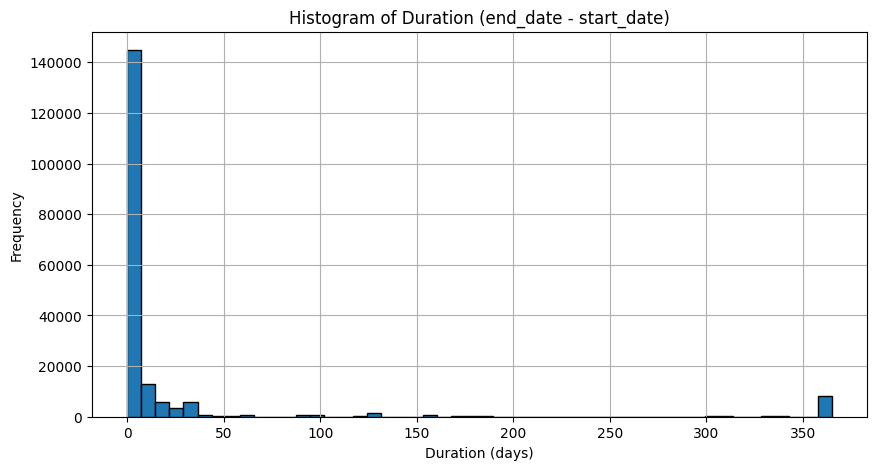


📅 Start Dates by Month:
 start_month
1     22327
2     10743
3     12948
4     15833
5     16342
6     16175
7     16182
8     19422
9     16484
10    16097
11    12898
12    12838
Name: count, dtype: int64

📅 End Dates by Month:
 end_month
1     10013
2      9288
3     13678
4     15027
5     15879
6     17659
7     15702
8     17466
9     17472
10    17351
11    15668
12    23086
Name: count, dtype: int64


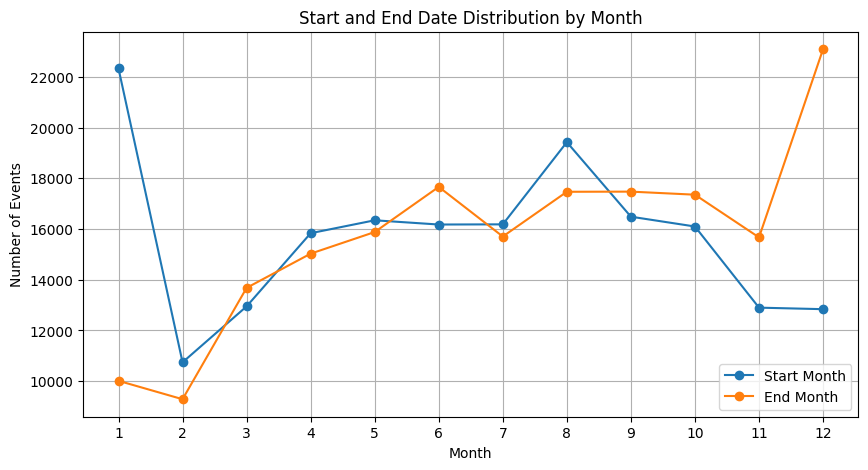

In [60]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Upload CSV file
uploaded = files.upload()

# Step 2: Load CSV into DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, parse_dates=["start_date", "end_date", "updatedDate"])

# Step 3: Basic date range checks
print("🗓️ Date Range Summary")
print("Start Date:", df["start_date"].min(), "→", df["start_date"].max())
print("End Date:  ", df["end_date"].min(), "→", df["end_date"].max())

# Step 4: Duration and statistics
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days
print("\n📊 Duration Stats:")
print(df["duration_days"].describe())

# Step 5: Histogram of durations
plt.figure(figsize=(10, 5))
plt.hist(df["duration_days"].dropna(), bins=50, edgecolor='black')
plt.title("Histogram of Duration (end_date - start_date)")
plt.xlabel("Duration (days)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Step 6: Monthly distribution of start and end dates
df["start_month"] = df["start_date"].dt.month
df["end_month"] = df["end_date"].dt.month

start_counts = df["start_month"].value_counts().sort_index()
end_counts = df["end_month"].value_counts().sort_index()

print("\n📅 Start Dates by Month:\n", start_counts)
print("\n📅 End Dates by Month:\n", end_counts)

plt.figure(figsize=(10, 5))
plt.plot(start_counts.index, start_counts.values, label="Start Month", marker='o')
plt.plot(end_counts.index, end_counts.values, label="End Month", marker='o')
plt.title("Start and End Date Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()


In [61]:
df = df.drop(columns=["frequency_tag"])


In [62]:
# Calculate % filled per column
total_rows = len(df)
percent_filled = df.notnull().sum() / total_rows * 100

# Create and display summary
filled_summary = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})

print(filled_summary)


               Total Rows  % Filled
updatedDate        188289    100.00
start_date         188289    100.00
end_date           188289    100.00
action_type        188289    100.00
party              188289     92.41
price              188289    100.00
price_basis        188289     81.91
grade              188289     92.41
incoterm           188289     83.13
location           188289     84.76
volume_min         188289     63.38
volume_max         188289     63.38
headline           188289    100.00
duration_days      188289    100.00
start_month        188289    100.00
end_month          188289    100.00


In [63]:
print(df.sample(1))


      updatedDate start_date   end_date action_type    party  price  \
41843  2022-09-09 2022-08-27 2022-09-17       Lower  VITOLSG  386.0   

      price_basis  grade incoterm location  volume_min  volume_max  \
41843    MOPS 380  380.0      FOB  Straits        20.0        20.0   

                                                                                                                       headline  \
41843  Platts HSFO 380cst FOB Straits 15-30, VITOLSG lowers offer Sep 29-Oct 3 100% MOPS 380 Flat Price $386.00  for 20-20 "inc   

       duration_days  start_month  end_month  
41843             21            8          9  


In [64]:
# Calculate duration if not already done
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days

# Summary stats
median_duration = df["duration_days"].median()

# Define outliers: durations > median + 3 * IQR
Q1 = df["duration_days"].quantile(0.25)
Q3 = df["duration_days"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

# Count outliers
outliers = df[df["duration_days"] > upper_bound]
num_outliers = len(outliers)

print(f"Median duration: {median_duration} days")
print(f"Outliers (duration > {upper_bound} days): {num_outliers} rows")


Median duration: 4.0 days
Outliers (duration > 12.0 days): 32915 rows


In [65]:
# Step 1: Calculate IQR bounds
Q1 = df["duration_days"].quantile(0.25)
Q3 = df["duration_days"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Upper Bound for Outliers: {upper_bound}")

# Step 2: Filter outliers
outliers = df[df["duration_days"] > upper_bound]

# Step 3: Sample 10 outliers to inspect
sample_outliers = outliers[["headline", "start_date", "end_date", "duration_days"]].sample(10, random_state=42)

print("\nSample Outliers:")
print(sample_outliers)


Q1: 4.0
Q3: 6.0
IQR: 2.0
Upper Bound for Outliers: 12.0

Sample Outliers:
                                                                                                                        headline  \
88102   Platts HSFO 180cst FOB Straits 15-30, GUNVORSG raises bid Jun 5-Jun 9 100% MOPS 180 5 Day $-14.00  for 20-20 "INCO " OCO   
98284   Asia 1232: Platts HSFO 380cst FOB Straits 15-30, TOTALSG lowers offer Nov 27-Dec 1 100% MOPS 380 5 Day $44.00  for 20-20   
178575                                                                                       platts hsfo trade summary: 3 trades   
58602   Platts HSFO 380cst FOB Straits 15-30, TOTALSG lowers offer Nov 3-Nov 7 100% MOPS 380 BalMnth Bal Month $10.00  for 20-20   
117917  Asia 867: Platts HSFO 380cst FOB Straits 15-30, GLENCORESG lowers offer May 2-May 6 100% MOPS 380 5 Day $0.00  for 20-20   
175876                                                                           platts hsfo trade summary: 12 trades (part 1/3)   
17

In [66]:
# Count unique action_type values (including NaNs if any)
action_type_counts = df["action_type"].value_counts(dropna=False)

# Convert to DataFrame for display
action_type_summary = action_type_counts.rename_axis('Action Type').reset_index(name='Count')

print("📋 Unique Action Types and Counts:")
print(action_type_summary)


📋 Unique Action Types and Counts:
     Action Type  Count
0          Lower  59210
1          Raise  46820
2          Offer  32111
3            Bid  29288
4       No Trade  19754
5  Trade Summary   1106


In [67]:
# Get one sample row per action_type
sample_rows = df.groupby("action_type").apply(lambda x: x.sample(1, random_state=42))

# Print headline and action_type columns
for idx, row in sample_rows.iterrows():
    print(f"Action Type: {row['action_type']}\nHeadline: {row['headline']}\n{'-'*60}\n")


Action Type: Bid
Headline: Platts HSFO 380cst FOB Straits 15-30, SINOPECHKSG  bids Jun 11-Jun 15 100% MOPS 380 5 Day $5.00  for 40-40 "INCO" OCO  7
------------------------------------------------------------

Action Type: Lower
Headline: Asia 478: Platts HSFO 380cst FOB Straits 15-30, MERCURIASG lowers offer Dec 30-Jan 3 100% MOPS 380 Flat Price $410.00  f
------------------------------------------------------------

Action Type: No Trade
Headline: Asia 212: Platts HSFO 380CST: Nov 29 - Dec 3 pegged at MOPS -2.21, bal Nov Avg -2.97, Dec Avg -0.97, Flat Price 221.03
------------------------------------------------------------

Action Type: Offer
Headline: asia 1379: platts hsfo: physical offers finals on close (180 cst)
------------------------------------------------------------

Action Type: Raise
Headline: Asia 869: Platts HSFO 380cst FOB Straits 15-30, GUNVORSG raises bid Aug 18-Aug 22 100% MOPS 380 5 Day $13.00  for 40-40 
----------------------------------------------------------

<ipython-input-67-a3fd38d7b528>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_rows = df.groupby("action_type").apply(lambda x: x.sample(1, random_state=42))


In [68]:
# Filter for Trade Summary rows
trade_summary_rows = df[df["action_type"] == "Trade Summary"]

# Sample 5 random rows and print headline + dates
sample_trade_summary = trade_summary_rows[["headline", "start_date", "end_date"]].sample(5, random_state=42)

print(sample_trade_summary)


                                                                                          headline  \
177936                                                          platts hsfo trade summary: 1 trade   
182693                                           asia 2125: platts hsfo trade summary: four trades   
174750  nov 15 2024: hsfo/mf 0.5%/bitumen platts asia trade summary: 1 hsfo trade 14:36:35.848 gmt   
182281                                           asia 1779: platts hsfo trade summary: five trades   
179696                                                          platts hsfo trade summary: 1 trade   

       start_date   end_date  
177936 2022-01-01 2022-12-01  
182693 2019-01-01 2019-11-01  
174750 2024-11-10 2024-12-18  
182281 2019-01-01 2019-11-01  
179696 2021-01-01 2021-12-01  


In [69]:
# Drop rows where action_type is 'Trade Summary'
df = df[df["action_type"] != "Trade Summary"].reset_index(drop=True)

# Print total rows after drop
total_rows = len(df)

# Calculate % filled per column
percent_filled = df.notnull().sum() / total_rows * 100
filled_summary = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})

print(f"🗂️ Dataset after dropping 'Trade Summary' rows:")
print(f"Total Rows: {total_rows}")
print(filled_summary)


🗂️ Dataset after dropping 'Trade Summary' rows:
Total Rows: 187183
               Total Rows  % Filled
updatedDate        187183    100.00
start_date         187183    100.00
end_date           187183    100.00
action_type        187183    100.00
party              187183     92.95
price              187183    100.00
price_basis        187183     82.39
grade              187183     92.95
incoterm           187183     83.63
location           187183     85.26
volume_min         187183     63.76
volume_max         187183     63.76
headline           187183    100.00
duration_days      187183    100.00
start_month        187183    100.00
end_month          187183    100.00


In [70]:
no_trade_rows = df[df["action_type"] == "No Trade"]

sample_no_trade = no_trade_rows["headline"].sample(50, random_state=42)

for i, headline in enumerate(sample_no_trade, 1):
    print(f"{i}. {headline}\n")


1. Asia 212: Platts HSFO 380CST: Nov 29 - Dec 3 pegged at MOPS -2.21, bal Nov Avg -2.97, Dec Avg -0.97, Flat Price 221.03

2. Platts HSFO 180CST: Nov 10 - Nov 14 pegged at MOPS  11, Nov Avg  11.49, Dec Avg 16.49, Flat Price 273.99

3. Asia 106: Platts HSFO 380CST: Feb 27 - Mar 3 pegged at MOPS +3.49, Bal Feb Avg 1.57, Mar Avg 5.82, Flat Price 405.82

4. Platts HSFO 180CST: Mar 11 - Mar 16 pegged at MOPS -6.16, Bal Feb Avg -7.94, Mar Avg -5.94, Flat Price 406.56

5. Asia 244: Platts HSFO 380CST: Nov 17 - Nov 22 pegged at MOPS 34.42, Nov Avg 31.25, Dec Avg 56.25, Flat Price 286

6. Platts FUJ HSFO 380CST: Jan 2 - Jan 6 pegged at FOB Fuj 18, Dec Avg 17.27, Jan Avg 18.52, Flat Price 290.07 7:44:06.674 

7. Asia 186: Platts FUJ HSFO 380CST: Mar 13 - Mar 18 pegged at FOB Fuj  4.5, Bal Feb Avg 3.76, Mar Avg 4.51, Flat Price 366

8. Platts HSFO 180CST: Nov 8 - Nov 13 pegged at MOPS 1.83, Oct Avg -0.11, Nov Avg 2.34, Flat Price 260.09 7:28:28.888 GMT

9. Asia 127: Platts HSFO 180CST: Mar 14 - M

In [71]:
# Filter rows with action_type == "No Trade"
no_trade_df = df[df["action_type"] == "No Trade"]

# Calculate % filled per column in filtered subset
total_rows = len(no_trade_df)
percent_filled = no_trade_df.notnull().sum() / total_rows * 100

# Create and display summary
filled_summary = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})

print(f"🗂️ % Filled for 'No Trade' Rows (Total Rows: {total_rows}):")
print(filled_summary)


🗂️ % Filled for 'No Trade' Rows (Total Rows: 19754):
               Total Rows  % Filled
updatedDate         19754    100.00
start_date          19754    100.00
end_date            19754    100.00
action_type         19754    100.00
party               19754     99.39
price               19754    100.00
price_basis         19754      0.00
grade               19754     99.39
incoterm            19754     39.71
location            19754     59.06
volume_min          19754      0.00
volume_max          19754      0.00
headline            19754    100.00
duration_days       19754    100.00
start_month         19754    100.00
end_month           19754    100.00


In [72]:
# Split datasets
df_no_trade = df[df["action_type"] == "No Trade"].copy()
df_active = df[df["action_type"] != "No Trade"].copy()


In [73]:
from google.colab import files

# Save No Trade dataset
no_trade_filename = "heards_structured_cleaned_09_No_Trade.csv"
df_no_trade.to_csv(no_trade_filename, index=False)
files.download(no_trade_filename)

# Save Active Trades dataset
trades_filename = "heards_structured_cleaned_09_Trades.csv"
df_active.to_csv(trades_filename, index=False)
files.download(trades_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
total_rows = len(df_active)
percent_filled = df_active.notnull().sum() / total_rows * 100

filled_summary = pd.DataFrame({
    "Total Rows": total_rows,
    "% Filled": percent_filled.round(2)
})

print(f"🗂️ Stats for Active Trades Dataset:")
print(filled_summary)


🗂️ Stats for Active Trades Dataset:
               Total Rows  % Filled
updatedDate        167429    100.00
start_date         167429    100.00
end_date           167429    100.00
action_type        167429    100.00
party              167429     92.19
price              167429    100.00
price_basis        167429     92.12
grade              167429     92.19
incoterm           167429     88.81
location           167429     88.35
volume_min         167429     71.28
volume_max         167429     71.28
headline           167429    100.00
duration_days      167429    100.00
start_month        167429    100.00
end_month          167429    100.00


📊 Price Summary Statistics:
count    167429.000000
mean         75.572555
std         138.735891
min        -100.000000
25%           1.000000
50%           5.000000
75%          25.000000
max         673.000000
Name: price, dtype: float64


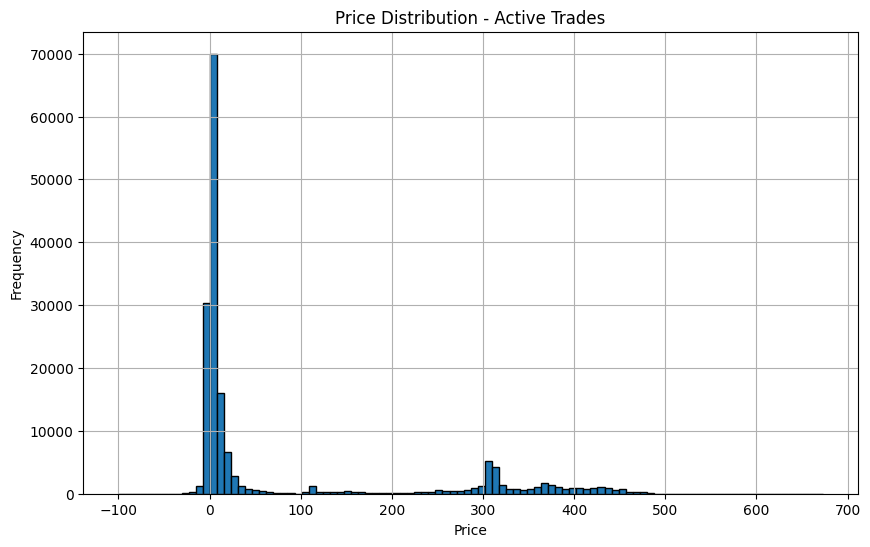

In [75]:
import matplotlib.pyplot as plt

# Summary statistics for price
price_stats = df_active["price"].describe()

print("📊 Price Summary Statistics:")
print(price_stats)

# Histogram of price
plt.figure(figsize=(10, 6))
plt.hist(df_active["price"].dropna(), bins=100, edgecolor='black')
plt.title("Price Distribution - Active Trades")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [77]:
# Filter rows with non-null price_basis
df_price_basis = df_active[df_active["price_basis"].isna()]

# Summary statistics for price in filtered data
price_stats_filtered = df_price_basis["price"].describe()

print("📊 Price Summary Statistics (price_basis present):")
print(price_stats_filtered)


📊 Price Summary Statistics (price_basis present):
count    13201.000000
mean       269.367959
std         75.413903
min          6.675100
25%        246.706839
50%        306.531794
75%        312.632611
max        546.628892
Name: price, dtype: float64
